In [41]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/YouTube/bin/python


In [42]:
import sys
print(sys.version)


3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:31:09) [GCC 11.2.0]


TAREFA: Base de dados CIFAR-10
Olá!

Nas aulas anteriores você aprendeu como utilizar a base de dados MNIST para classificação de dígitos escritos a mão. Além dela, outra base de dados bastante famosa é a CIFAR-10, que é utilizada para classificação de 10 classes, ou seja: avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio e caminhão. Clicando no link abaixo você pode ver mais detalhes sobre ela

CIFAR-10 https://www.cs.toronto.edu/~kriz/cifar.html

Utilizando esta base de dados, o objetivo é você construir uma rede neural conforme desenvolvemos nas aulas sobre o MNIST, avaliando os percentuais de acerto que você obterá testando diversas configurações com a rede neural convolucional. No link abaixo você pode verificar quais foram os percentuais máximos de acerto atingidos por outros pesquisadores

Acertos base CIFAR-10 https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#43494641522d3130

Siga as seguintes dicas para concluir esta tarefa:

Consulte a documentação do PyTorch para aprender como carregar essa base de dados => https://docs.pytorch.org/docs/stable/index.html

A dimensão das imagens é 32 x 32 e elas são coloridas, portanto, você deve fazer esses ajustes no código fonte

Quando avaliamos algoritmos de aprendizagem de máquina, o ideal é utilizar validação cruzada. Porém, para não aumentarmos o tempo de processamento, você pode utilizar as bases de treinamento e teste para esta tarefa

Abaixo você pode consultar o colab com a solução para essa tarefa

Solução para a tarefa

##  48.0) Tarefa: Redes Convolucional CIFAR-10

## Etapa 1: Importação das bibliotecas

In [43]:
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

In [44]:
# semente, gerar sempre omesmo valor
torch.manual_seed(123)

In [45]:
transform = transforms.ToTensor()

In [46]:
# coletando os dados
train = datasets.CIFAR10(root = '.', train = True, download = True, transform = transform)
test = datasets.CIFAR10(root = '.', train = False, download = True, transform = transform)

Text(0.5, 1.0, 'Classe frog')

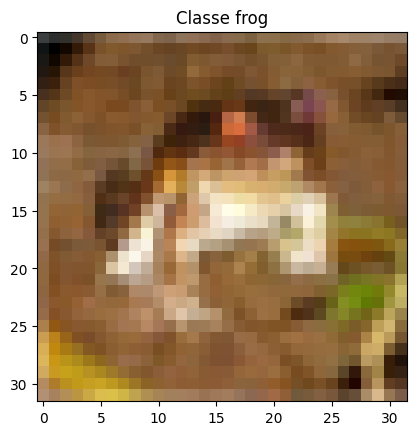

In [47]:
plt.imshow(train.data[0])
plt.title('Classe ' + str(train.classes[train.targets[0]]))

Text(0.5, 1.0, 'Classe automobile')

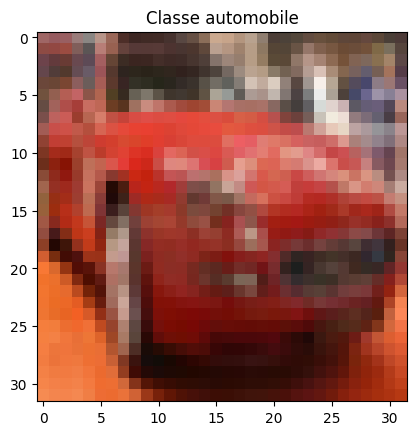

In [48]:
plt.imshow(train.data[5])
plt.title('Classe ' + str(train.classes[train.targets[5]]))

Text(0.5, 1.0, 'Classe horse')

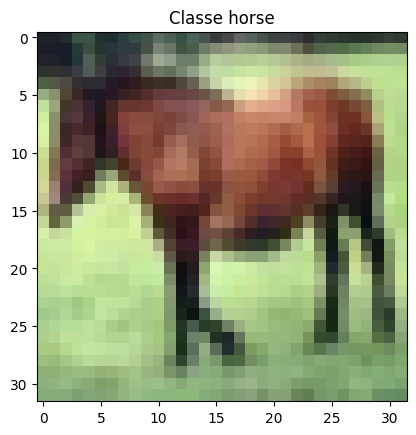

In [49]:
plt.imshow(train.data[7])
plt.title('Classe ' + str(train.classes[train.targets[7]]))

In [50]:
# O DataLoader automatiza a entrega de dados para o modelo
train_loader = torch.utils.data.DataLoader(
    train,            # O conjunto de dados (dataset) que será lido
    batch_size = 128, # Define que a rede receberá 128 imagens de cada vez (um lote)
  #  shuffle = True    # Geralmente adicionamos isso no treino para embaralhar os dados
)

# Faz o mesmo para o teste, mas geralmente sem necessidade de embaralhar (shuffle=False)
test_loader = torch.utils.data.DataLoader(
    test, 
    batch_size = 128
)

## Etapa 3: Construção do modelo

In [51]:
#Chama o "Nascimento" da Classe Pai: O nn.Module (criado pelos desenvolvedores do PyTorch) tem uma série de configurações 
#complexas internas (gerenciamento de parâmetros, suporte a GPU, rastreamento de gradientes).

class classificador(nn.Module):
    def __init__(self):
        #Autorização: Sem o super().__init__(), o PyTorch não conseguiria "registrar" 
        #as camadas que você cria (como nn.Conv2d ou nn.Linear). 
        #A sua classe seria apenas uma classe comum e não uma rede neural funcional.
        super().__init__()

        # --- CAMADAS DE EXTRAÇÃO DE CARACTERÍSTICAS (CONVOLUCIONAIS) ---
        
        # Conv1: Recebe imagem colorida (3 canais: R, G, B) e aplica 32 filtros 3x3.
        
        #*kernel_size = (3, 3) (O Filtro/Lupa)O Kernel é uma pequena matriz (neste caso, de 3 x 3pixels) 
        #que desliza sobre a imagem original.O que ele faz: Ele funciona como uma "lupa" que procura padrões específicos,
        #como linhas verticais, horizontais ou curvas.A conta: 
        #Ele multiplica os valores dos pixels da imagem pelos pesos que a rede está aprendendo e soma tudo, gerando um novo valor.

        # * out_channels = 32 (A Quantidade de Filtros) Esse valor define o número de "mapas de características" que a camada vai criar.      
        # O que faz: Imagine que você tem 32 pessoas diferentes olhando para a mesma imagem.        
        # A pessoa 1 procura apenas bordas.        
        # A pessoa 2 procura apenas texturas.        
        # A pessoa 3 procura círculos.        
        # O resultado: Ao final dessa camada, você não terá mais apenas uma imagem, 
        # mas sim 32 versões diferentes daquela imagem, cada uma destacando uma característica que a rede achou importante.

        # kernel_size = (3, 3) -> O tamanho da "janela" que escaneia a imagem.
        # out_channels = 32   -> A rede criará 32 "detetives" diferentes para achar padrões.
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = (3, 3))

        
        # Conv2: Recebe os 32 mapas da anterior e aplica mais 32 filtros para refinar padrões.
        # Camada que refina a extração de características
        self.conv2 = nn.Conv2d(
            32,      # in_channels: Recebe os 32 mapas que a camada anterior criou.
            32,      # out_channels: Cria 32 novos mapas de características ainda mais detalhados.
            (3, 3)   # kernel_size: Usa filtros de 3x3 pixels para escanear os mapas anteriores.
        )

        # ReLU (Rectified Linear Unit): Define a regra de ativação dos neurônios
        # Ativação ReLU: Introduz não-linearidade (zera valores negativos).
        self.activation = nn.ReLU()
        
        # BatchNorm: Normaliza as saídas das convoluções para o treino ser mais rápido e estável.
        self.bnorm = nn.BatchNorm2d(num_features = 32)
        
        # MaxPool: Reduz a resolução espacial (largura e altura) pela metade, focando no que é importante.
        self.pool = nn.MaxPool2d(kernel_size = (2, 2))
        
        # Flatten: "Achata" os mapas 2D em um único vetor longo para entrar na rede clássica.
        self.flatten = nn.Flatten()

        # --- CAMADAS DE CLASSIFICAÇÃO (DENSAS / LINEARES) ---
        
        # Linear1: Recebe o vetor (32 mapas de 6x6) e conecta a 128 neurônios.
        # in_features = 32*6*6:
        # 32 é a profundidade (número de filtros da última conv).
        # 6x6 é o que sobrou do tamanho da imagem após as reduções (Pooling e Conv).
        # A camada Linear precisa saber exatamente quantos números "entrarão" nela.
        self.linear1 = nn.Linear(in_features = 32*6*6, out_features = 128)
        
        # Linear2: Camada oculta extra com mais 128 neurônios para processar lógica complexa.
        self.linear2 = nn.Linear(128, 128)
        
        # Output: Camada final que reduz para 10 saídas (uma para cada categoria/classe).
        self.output = nn.Linear(128, 10)

        # Dropout: Desativa 20% dos neurônios aleatoriamente no treino para evitar que a rede "decore" (overfitting).
        self.dropout = nn.Dropout(p = 0.2)

    def forward(self, X):
        # BLOCO 1: Convolução -> Ativação -> Normalização -> Redução (Pooling)
        X = self.pool(self.bnorm(self.activation(self.conv1(X))))
        
        # BLOCO 2: Repete o processo para extrair características de nível mais alto
        X = self.pool(self.bnorm(self.activation(self.conv2(X))))
        
        # Prepara para as camadas lineares
        X = self.flatten(X)

        # CLASSIFICAÇÃO: Processa com Dropout para garantir que a rede seja robusta
        X = self.dropout(self.activation(self.linear1(X)))
        X = self.dropout(self.activation(self.linear2(X)))
        
        # Decisão final
        X = self.output(X)

        return X

self.linear1 = nn.Linear(in_features = 32*6*6, out_features = 128)


Usando imagens de 32x32 (como no dataset CIFAR-10), aqui está a conta que explica o 6x6:

📏 O Caminho da Imagem (Cálculo de Dimensões)

- Entrada: Começa com uma imagem de $32 \times 32$.

- Conv1 (3x3): Como o filtro tem tamanho 3, ele "perde" 2 pixels de cada lado (sem padding).Resultado: $30 \times 30$.



- Pool1 (2x2): O Pooling divide a altura e largura por 2.Resultado: $15 \times 15$.



- Conv2 (3x3): Novamente, o filtro 3x3 reduz a dimensão em 2 pixels.Resultado: $13 \times 13$.

- Pool2 (2x2): Divide por 2 novamente. O PyTorch arredonda para baixo ($13 \div 2 = 6.5 \rightarrow 6$).Resultado Final Espacial: $6 \times 6$.

Por que multiplicar por 32?

O out_channels da última convolução foi 32. Isso significa que não tem apenas uma imagem de 6x6, mas sim 32 "mini imagens" (mapas de características) de 6x6 cada.

Para a camada Linear entender isso, o nn.Flatten() estica todos esses quadradinhos em uma fila única de pixels:

$$32 \text{ filtros} \times 6 \text{ pixels (altura)} \times 6 \text{ pixels (largura)} = 1.152 \text{ neurônios de entrada}$$

In [52]:
net = classificador()            # 1. Cria a rede (o cérebro)
criterion = nn.CrossEntropyLoss() # 2. Define a regra do erro (a régua)
optimizer = optim.Adam(net.parameters()) # 3. Define quem ajusta os pesos (o motor)

1. net = classificador()
O Objeto do Modelo

O que faz: Cria uma "instância" (uma cópia viva) da estrutura que se desenhou na classe classificador.

Na prática: É aqui que o computador reserva espaço na memória e cria os pesos e vieses iniciais (que começam com valores aleatórios). Agora net é o seu cérebro artificial pronto para ser treinado.

2. criterion = nn.CrossEntropyLoss()
A "Prova" ou Medidor de Erro

O que faz: Define a fórmula matemática para calcular o quão longe a rede está da resposta certa.

Na prática: Para classificação (como CIFAR-10 ou MNIST), a CrossEntropy é a escolha padrão. Ela penaliza severamente a rede se ela estiver muito confiante em um palpite errado. O objetivo do treino é fazer esse valor de "perda" (loss) chegar o mais próximo de zero possível.

3. optimizer = optim.Adam(net.parameters())
O Mecanismo de Ajuste (O "Professor")

O que faz: É o algoritmo que realmente altera os pesos da rede para diminuir o erro calculado pelo criterion.

net.parameters(): Você está dizendo ao Adam: "Estes são os pesos que se tem permissão para mexer".

Adam: É um otimizador moderno e muito popular porque ele ajusta a velocidade do aprendizado sozinho durante o treino, o que o torna muito mais rápido e estável que o clássico SGD (Gradiente Descendente).

## Etapa 4: Treinamento do modelo

In [53]:
device = torch.device('cuda') if torch.cuda.is_available else torch.devide('cpu')
device

device(type='cuda')

In [54]:
# correção
device = torch.device('cpu') if torch.cuda.is_available else torch.devide('cuda')
device

device(type='cpu')

In [55]:
net.to(device)

classificador(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (activation): ReLU()
  (bnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=1152, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [56]:
def training_loop(loader, epoch):
    # Inicializa os acumuladores para calcular a média de erro e acerto da época inteira
    running_loss = 0.
    running_accuracy = 0.

    # 1. ENUMERATE: Percorre o DataLoader pegando os lotes (ex: 128 imagens por vez)
    for i, data in enumerate(loader):
        inputs, labels = data
        # Envia os dados para o hardware correto (CPU ou GPU/Cuda)
        inputs, labels = inputs.to(device), labels.to(device)

        # 2. ZERO_GRAD: Limpa a memória de erros anteriores. 
        # Sem isso, o erro atual se somaria ao antigo, estragando o aprendizado.
        optimizer.zero_grad()

        # 3. FORWARD: A rede neural processa as imagens e gera as previsões (outputs)
        outputs = net(inputs)

        # --- CÁLCULO DE PRECISÃO (ACURÁCIA) ---
        # Pega a classe com o maior valor de confiança
        top_p, top_class = outputs.topk(k = 1, dim = 1)
        # Compara se a previsão é igual ao gabarito (labels)
        equals = top_class == labels.view(*top_class.shape)
        # Transforma True/False em números (1.0 ou 0.0) e tira a média
        accuracy = torch.mean(equals.type(torch.float))
        running_accuracy += accuracy

        # 4. LOSS: Calcula o quão longe a rede passou do alvo usando o critério (CrossEntropy)
        loss = criterion(outputs, labels)

        # 5. BACKWARD: O "Caminho de Volta". O PyTorch calcula quanto cada neurônio 
        # contribuiu para o erro.
        loss.backward()

        # 6. STEP: O otimizador (Adam) efetivamente altera os pesos da rede para consertar o erro.
        optimizer.step()

        # Soma o valor numérico do erro para o relatório final
        running_loss += loss.item()

        # Imprimindo os dados referentes a esse loop
        # Imprime o progresso em tempo real na mesma linha (\r)
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:03.2f} - precisão {:03.2f}'.format(epoch + 1, i + 1,
                                                                                               len(loader),
                                                                                               loss, accuracy), end = '\r')
    
    # Imprimindo os dados referentes a essa época
    # FINAL DA ÉPOCA: Exibe a média de perda e precisão de todos os lotes combinados
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, 
                                                                            running_loss/len(loader), 
                                                                            running_accuracy/len(loader)))

In [57]:
for epoch in range(5):
    print('Treinando...')
    training_loop(train_loader, epoch)

    net.eval()
    print('Validando...')
    training_loop(test_loader, epoch)

    net.train()

Treinando...
ÉPOCA   1 FINALIZADA: perda 1.36302 - precisão 0.509914
Validando...
ÉPOCA   1 FINALIZADA: perda 1.45965 - precisão 0.494869
Treinando...
ÉPOCA   2 FINALIZADA: perda 1.04692 - precisão 0.632752
Validando...
ÉPOCA   2 FINALIZADA: perda 1.23038 - precisão 0.561811
Treinando...
ÉPOCA   3 FINALIZADA: perda 0.91415 - precisão 0.681980
Validando...
ÉPOCA   3 FINALIZADA: perda 1.08720 - precisão 0.613831
Treinando...
ÉPOCA   4 FINALIZADA: perda 0.82182 - precisão 0.713193
Validando...
ÉPOCA   4 FINALIZADA: perda 1.03733 - precisão 0.631631
Treinando...
ÉPOCA   5 FINALIZADA: perda 0.75226 - precisão 0.738099
Validando...
ÉPOCA   5 FINALIZADA: perda 0.91472 - precisão 0.681078


3. net.eval() (Modo de Avaliação)
Este comando é vital. Ele avisa à rede: "Pare de aprender e apenas me dê resultados estáveis".

Ele desativa o Dropout (para que todos os neurônios trabalhem, em vez de apenas 80%).

Ele trava o BatchNorm para usar as médias que ele aprendeu no treino, em vez de tentar calcular novas.

5. net.train() (Volta ao modo de Treino)
Após testar, este comando religa as funções de aprendizado (como o Dropout) para que a rede esteja pronta para a próxima época de estudos.

## Depois de treinar a rede, o processo de previsão (também chamado de Inferência) é bem mais simples

1. Colocar a rede em modo de avaliaçãoSempre use net.eval().

   Isso desativa o Dropout e garante que a previsão seja estável.

2. Preparar a imagem

   A imagem precisa estar no mesmo formato que a rede aprendeu:

   - Ser um Tensor.
   - Ter as mesmas dimensões (ex: $1 \times 3 \times 32 \times 32$).
   - Estar no mesmo device (CPU ou GPU).

In [58]:
# para prever
import torch

# 1. Coloca em modo de teste
net.eval()

# 2. Pega uma imagem do loader de teste para testar
imagens, rotulos = next(iter(test_loader))
img = imagens[0].unsqueeze(0).to(device) # Pega a primeira imagem e adiciona dimensão de lote

# 3. Faz a previsão sem calcular gradientes (economiza memória)
with torch.no_grad():
    output = net(img)

# 4. A saída são 'logits'. Usamos Softmax para virar probabilidade (0 a 100%)
probabilidades = torch.nn.functional.softmax(output, dim=1)

# 5. Pega o índice do maior valor
valor_previsto = torch.argmax(probabilidades).item()

print(f"A rede previu: {valor_previsto}")
print(f"O rótulo real era: {rotulos[0].item()}")

A rede previu: 3
O rótulo real era: 3


🔍 O que está acontecendo aqui?

- unsqueeze(0): A rede espera um "lote" de imagens. Mesmo que você queira prever apenas uma, você precisa fingir que é um lote de tamanho 1. Isso transforma o formato de $(3, 32, 32)$ para $(1, 3, 32, 32)$.
  
- torch.no_grad(): Como não estamos treinando, não precisamos que o PyTorch gaste tempo e memória calculando derivadas.

- argmax: A camada de saída tem 10 neurônios. O argmax simplesmente te diz qual é a posição do neurônio com o maior valor (ex: se o neurônio na posição 7 for o maior, a rede acha que a imagem é um "7").

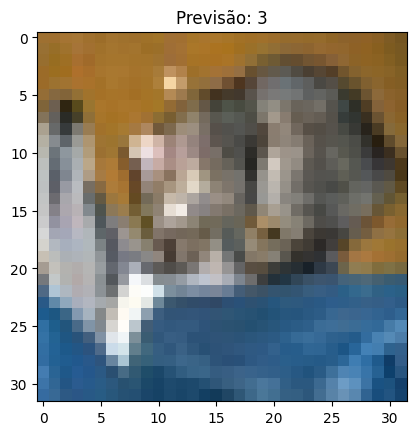

In [59]:
# Para ficar mais legal, você pode plotar a imagem antes de imprimir o resultado:

import matplotlib.pyplot as plt

# Converte de Tensor para imagem comum (Canais, Altura, Largura) -> (Altura, Largura, Canais)
plt.imshow(imagens[0].permute(1, 2, 0).cpu())
plt.title(f"Previsão: {valor_previsto}")
plt.show()

In [60]:
print(train.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [61]:
classes = train.classes

In [62]:
# Supondo que o resultado do argmax foi 3
indice = torch.argmax(probabilidades).item()

nome_da_classe = classes[indice]

print(f"A rede previu o índice {indice}, que corresponde a: {nome_da_classe}")

A rede previu o índice 3, que corresponde a: cat


In [63]:
net.eval()
with torch.no_grad():
    imagens, rotulos = next(iter(test_loader))
    output = net(imagens[0].unsqueeze(0).to(device))
    
    indice = torch.argmax(output).item()
    
    print(f"Previsão: {classes[indice]}")
    print(f"Real: {classes[rotulos[0].item()]}")

Previsão: cat
Real: cat


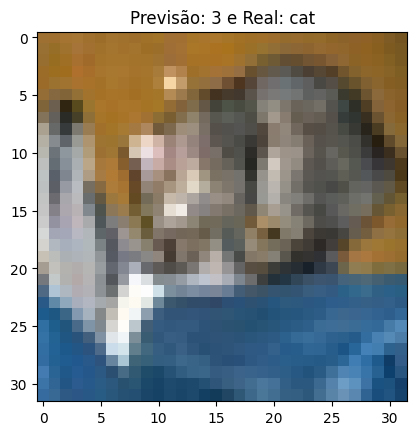

In [64]:
# Para ficar mais legal, você pode plotar a imagem antes de imprimir o resultado:

import matplotlib.pyplot as plt

# Converte de Tensor para imagem comum (Canais, Altura, Largura) -> (Altura, Largura, Canais)
plt.imshow(imagens[0].permute(1, 2, 0).cpu())
plt.title(f"Previsão: {valor_previsto} e Real: {classes[rotulos[0].item()]}")
plt.show()

(-0.5, 31.5, 31.5, -0.5)

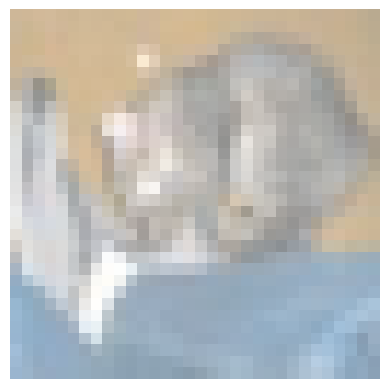

In [65]:
# Se usou transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
img = imagens[0] / 2 + 0.5     # Desfaz a normalização básica
plt.imshow(img.permute(1, 2, 0).cpu())
plt.axis('off') # Remove os números das bordas

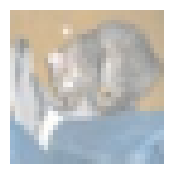

In [69]:
# 1. 'interpolation=none' impede o borrão
# 2. 'figsize' não pode ser muito grande para não esticar demais os pixels
plt.figure(figsize=(2, 2)) 

# Desnormalizando para as cores ficarem vivas
img = imagens[0] / 2 + 0.5 

# O segredo está no interpolation='nearest' ou 'none'
plt.imshow(img.permute(1, 2, 0).cpu(), interpolation='nearest') 

plt.axis('off') # Remove bordas que distraem
plt.show()

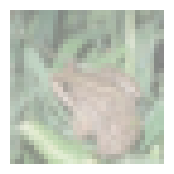

In [66]:
# 1. 'interpolation=none' impede o borrão
# 2. 'figsize' não pode ser muito grande para não esticar demais os pixels
plt.figure(figsize=(2, 2)) 

# Desnormalizando para as cores ficarem vivas
img = imagens[i] / 2 + 0.5 

# O segredo está no interpolation='nearest' ou 'none'
plt.imshow(img.permute(1, 2, 0).cpu(), interpolation='nearest') 

plt.axis('off') # Remove bordas que distraem
plt.show()

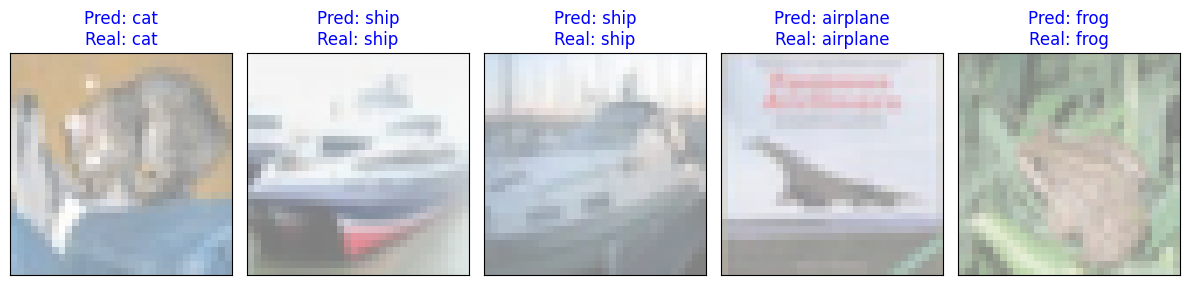

In [67]:
# 1. Coloca a rede em modo de teste e desativa o cálculo de gradientes
net.eval()
with torch.no_grad():
    # 2. Pega um lote de imagens de teste
    imagens, rotulos = next(iter(test_loader))
    imagens, rotulos = imagens.to(device), rotulos.to(device)

    # 3. Faz a previsão (FORWARD) - AQUI CRIAMOS O TOP_CLASS
    outputs = net(imagens)
    _, top_class = outputs.topk(k=1, dim=1) # Pega o índice da maior probabilidade

# 4. Agora sim, montamos o gráfico
fig = plt.figure(figsize=(12, 4))

for i in range(5): # Vamos ver as 5 primeiras imagens
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    
    # Prepara a imagem (Desnormaliza e move para CPU)
    img = imagens[i] / 2 + 0.5 
    plt.imshow(img.permute(1, 2, 0).cpu(), interpolation='nearest')
    
    # Pega o índice puro (inteiro) da previsão e do rótulo real
    idx_previsto = top_class[i].item()
    idx_real = rotulos[i].item()
    
    # Lógica da cor: Azul se acertou, Vermelho se errou
    cor = "blue" if idx_previsto == idx_real else "red"
    
    # Usa a lista 'classes' para traduzir o número em texto
    ax.set_title(f"Pred: {classes[idx_previsto]}\nReal: {classes[idx_real]}", color=cor)

plt.tight_layout()
plt.show()

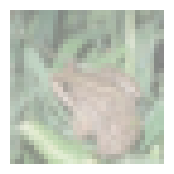

In [68]:
# 1. 'interpolation=none' impede o borrão
# 2. 'figsize' não pode ser muito grande para não esticar demais os pixels
plt.figure(figsize=(2, 2)) 

# Desnormalizando para as cores ficarem vivas
img = imagens[i] / 2 + 0.5 

# O segredo está no interpolation='nearest' ou 'none'
plt.imshow(img.permute(1, 2, 0).cpu(), interpolation='nearest') 

plt.axis('off') # Remove bordas que distraem
plt.show()